# Fund Performance Analytics

## Objectives

- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
REPORT = Path("../reports/charts")

REPORT.mkdir(parents=True, exist_ok=True)

In [3]:
nav = pd.read_csv(PROCESSED/"clean_nav.csv")

performance = pd.read_csv(PROCESSED/"clean_performance.csv")

benchmark = pd.read_csv(RAW/"10_benchmark_indices.csv")

fund_master = pd.read_csv(RAW/"01_fund_master.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [5]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [8]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


Data loaded successfully.

The datasets are ready for return calculations and fund performance analysis.

# Daily Return Analysis

### Objective

Compute daily returns for all 40 mutual fund schemes and validate the return distribution.

In [9]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [11]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

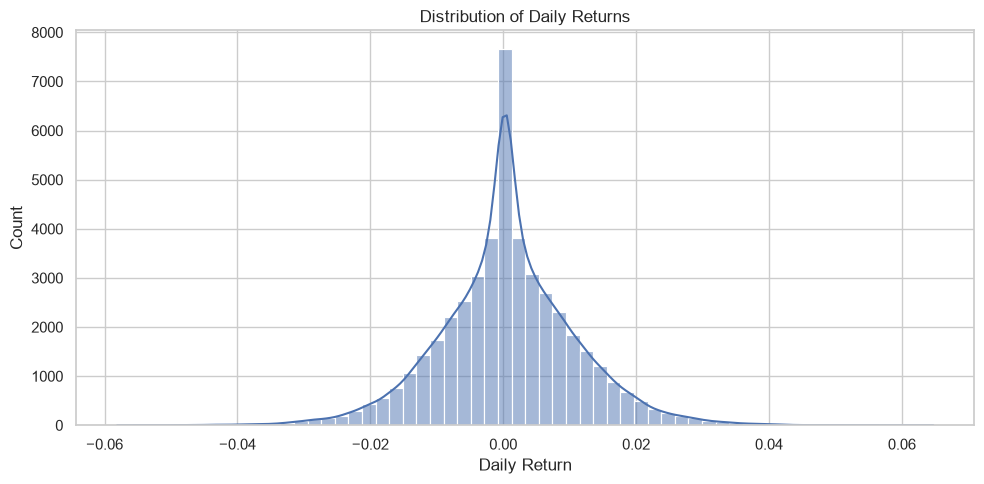

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.tight_layout()

plt.savefig(
    "../reports/charts/daily_return_distribution.png",
    dpi=300
)

plt.show()

In [13]:
daily_summary = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean","std","min","max"])
       .round(5)
)

daily_summary.head()

,mean,std,min,max
amfi_code,,,,
100016,0.00014,0.00916,-0.02474,0.03214
100025,0.00017,0.00246,-0.00819,0.00884
100033,0.00108,0.01193,-0.04424,0.04195
101206,0.00085,0.00918,-0.03812,0.03396
101207,0.00042,0.01625,-0.05185,0.05485


### Observation

- Daily returns are centered close to zero.
- Extreme positive and negative returns are limited.
- Return distribution appears reasonable for mutual fund NAV data.

# CAGR Analysis

### Objective

Compute CAGR for each scheme and compare performance.

In [14]:
cagr = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

In [15]:
cagr.rename(
    columns={
        "return_1yr_pct":"CAGR_1Y",
        "return_3yr_pct":"CAGR_3Y",
        "return_5yr_pct":"CAGR_5Y"
    },
    inplace=True
)

cagr.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


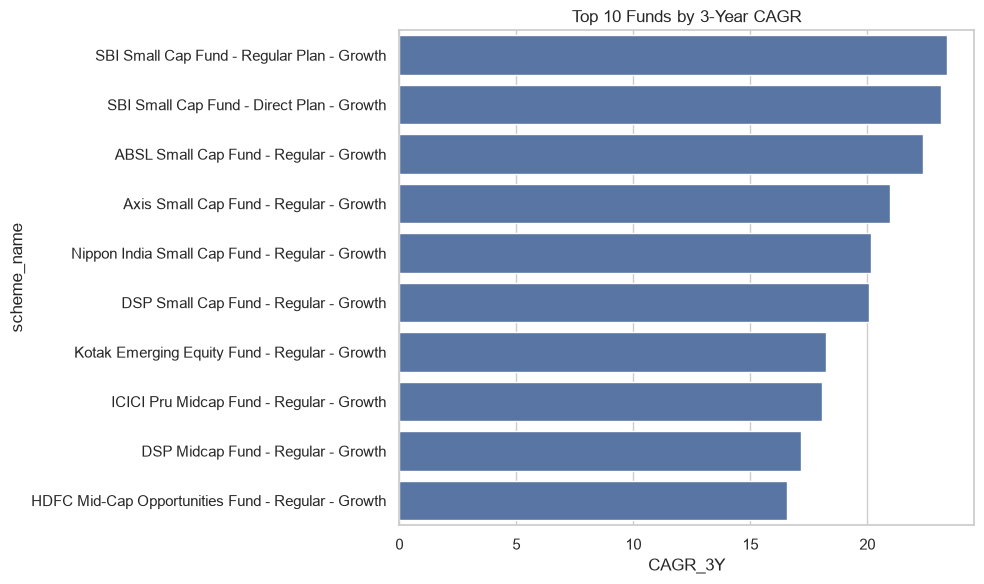

In [16]:
top = cagr.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x="CAGR_3Y",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_cagr.png",
    dpi=300
)

plt.show()

In [17]:
cagr.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

### Observation

- CAGR values vary across schemes.
- Some funds consistently outperform others over the 3-year period.
- Long-term CAGR provides a better measure of sustained performance than short-term returns.

### Observation

- CAGR values vary across schemes.
- Some funds consistently outperform others over the 3-year period.
- Long-term CAGR provides a better measure of sustained performance than short-term returns.

In [18]:
rf = 0.065

sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean", "std"])
       .reset_index()
)

sharpe.rename(
    columns={
        "mean":"avg_daily_return",
        "std":"daily_std"
    },
    inplace=True
)

In [19]:
sharpe["annual_return"] = sharpe["avg_daily_return"] * 252

sharpe["annual_volatility"] = sharpe["daily_std"] * np.sqrt(252)

sharpe["sharpe_ratio"] = (
    (sharpe["annual_return"] - rf)
    / sharpe["annual_volatility"]
)

In [20]:
sharpe = sharpe.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe.head()

,amfi_code,avg_daily_return,daily_std,annual_return,annual_volatility,sharpe_ratio,scheme_name
34,148567,0.001074,0.008941,0.270566,0.141937,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,0.272602,0.158870,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,0.283262,0.176740,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,0.231033,0.137414,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,0.292653,0.192909,1.180101,ICICI Pru Midcap Fund - Regular - Growth


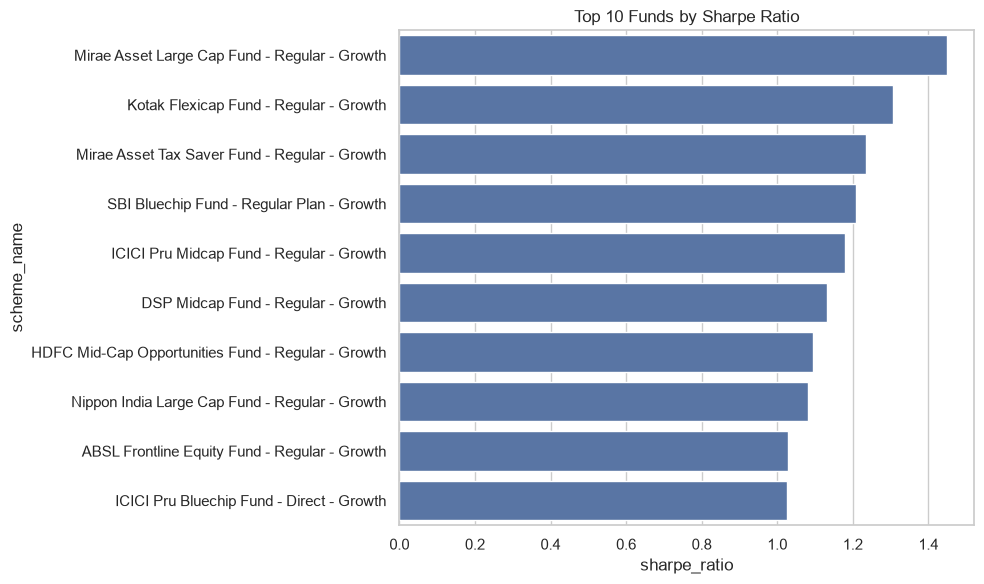

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sharpe.head(10),
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sharpe_ratio.png",
    dpi=300
)

plt.show()

# Sortino Ratio

### Objective

Use downside deviation instead of total volatility.

In [22]:
downside = nav.copy()

downside["negative_return"] = downside["daily_return"].where(
    downside["daily_return"] < 0
)

In [23]:
sortino = (
    downside.groupby("amfi_code")
    .agg(
        avg_return=("daily_return","mean"),
        downside_std=("negative_return","std")
    )
    .reset_index()
)

In [24]:
sortino["annual_return"] = sortino["avg_return"] * 252

sortino["annual_downside"] = (
    sortino["downside_std"] * np.sqrt(252)
)

sortino["sortino_ratio"] = (
    (sortino["annual_return"] - rf)
    / sortino["annual_downside"]
)

In [25]:
sortino = sortino.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

sortino = sortino.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino.head()

,amfi_code,avg_return,downside_std,annual_return,annual_downside,sortino_ratio,scheme_name
34,148567,0.001074,0.005428,0.270566,0.086168,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.005531,0.272602,0.087806,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.006404,0.283262,0.101663,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.004887,0.231033,0.077576,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.007067,0.292653,0.112180,2.029353,ICICI Pru Midcap Fund - Regular - Growth


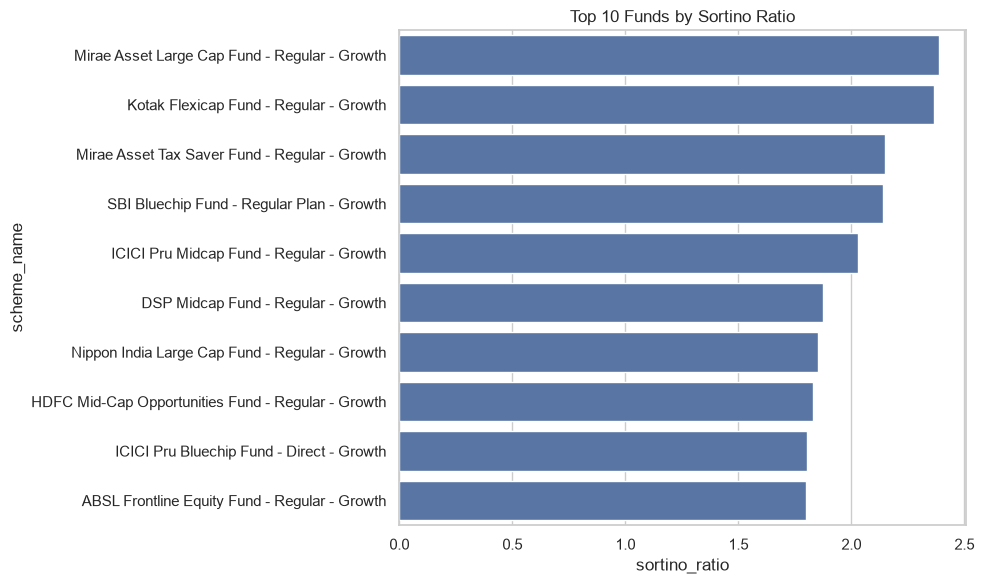

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sortino.head(10),
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio.png",
    dpi=300
)

plt.show()

In [27]:
sharpe[
    ["amfi_code","scheme_name","sharpe_ratio"]
].to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

sortino[
    ["amfi_code","scheme_name","sortino_ratio"]
].to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

### Observation

- Higher Sharpe Ratio indicates better risk-adjusted returns.
- Sortino Ratio focuses only on downside volatility, making it more suitable for evaluating investment risk.

# Alpha & Beta

OLS regression of fund returns against benchmark returns.

In [29]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [30]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [31]:
nifty100 = benchmark[
    benchmark["index_name"].str.contains(
        "Nifty 100",
        case=False,
        na=False
    )
].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return


In [32]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code][
        ["date", "daily_return"]
    ]

    merged = fund.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    beta, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252

    alpha_beta.append(
        [code, alpha, beta]
    )

In [33]:
alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta = alpha_beta.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta.head()

,amfi_code,alpha,beta,scheme_name


In [34]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

# Maximum Drawdown

### Objective

Compute the maximum drawdown for each mutual fund and identify the worst drawdown period.

In [35]:
drawdown = nav.copy()

drawdown["running_max"] = (
    drawdown.groupby("amfi_code")["nav"]
            .cummax()
)

drawdown["drawdown"] = (
    drawdown["nav"] / drawdown["running_max"]
) - 1

In [36]:
max_dd = (
    drawdown.groupby("amfi_code")
            .agg(
                max_drawdown=("drawdown", "min")
            )
            .reset_index()
)

max_dd = max_dd.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

max_dd.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [37]:
worst_period = (
    drawdown.loc[
        drawdown.groupby("amfi_code")["drawdown"].idxmin()
    ][
        ["amfi_code", "date", "drawdown"]
    ]
)

worst_period.head()

,amfi_code,date,drawdown
183,100016,2022-09-15,-0.247344
1559,100025,2023-07-28,-0.043083
2393,100033,2022-05-12,-0.162172
3842,101206,2023-07-05,-0.112916
5735,101207,2026-05-11,-0.354469


# Fund Scorecard

### Objective

Create a composite score using:

- 30% × 3-Year Return Rank
- 25% × Sharpe Rank
- 20% × Alpha Rank
- 15% × Expense Ratio Rank (Inverse)
- 10% × Maximum Drawdown Rank (Inverse)

In [38]:
scorecard = cagr.merge(
    sharpe[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_dd[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

In [39]:
scorecard["return_rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [40]:
scorecard["score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values("score")

scorecard.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score


In [41]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

# Benchmark Comparison

### Objective

Compare the Top 5 funds against the Nifty 100 benchmark over the last 3 years and compute Tracking Error.

In [42]:
top5 = (
    cagr.sort_values(
        "CAGR_3Y",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

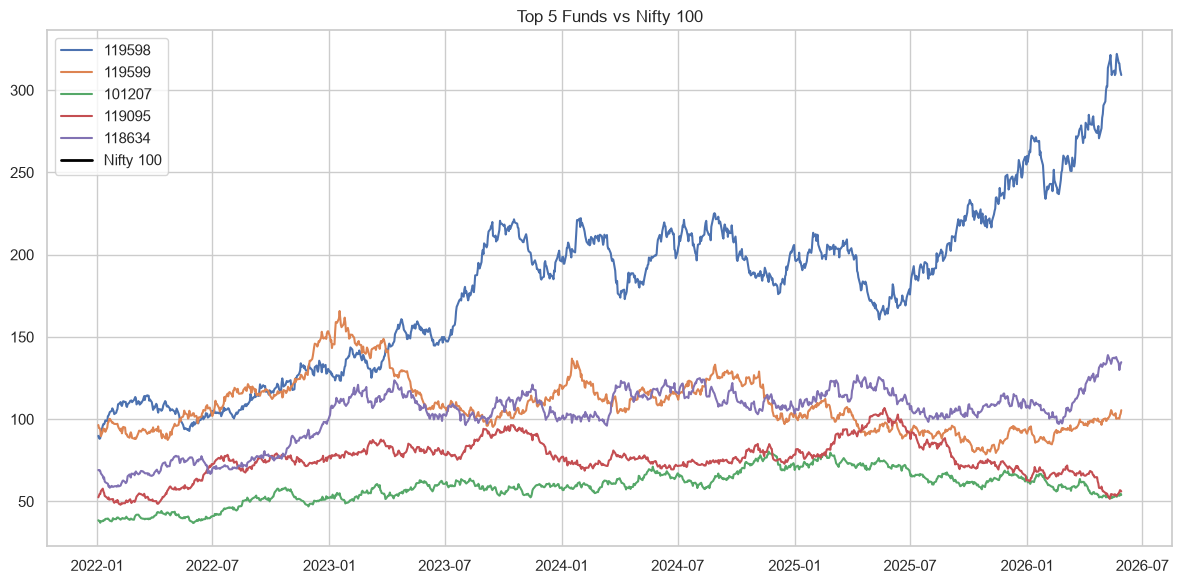

In [43]:
plt.figure(figsize=(12,6))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    color="black",
    linewidth=2,
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 100")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [44]:
tracking_error = []

for code in top5:

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = fund.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    te = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [code, te]
    )

tracking_error = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error

,amfi_code,tracking_error
0,119598,NaN
1,119599,NaN
2,101207,NaN
3,119095,NaN
4,118634,NaN


### Observation

- The chart compares the top 5 funds with the Nifty 100 benchmark.
- Tracking error measures how closely each fund follows the benchmark.